In [28]:
from climbprep.constants import *
from climbprep.util import *
from pathlib import Path
import nibabel as nib

project = 'climblab_multisession'
ica_label = 'fsnative'
node='subject'
participant='c001'
home_dir = os.path.join(out_root, "_qunex_home")
fmriprep_root = Path(os.path.join(BIDS_PATH, project)) / 'derivatives' / 'preprocess' / 'main' / f'sub-{participant}'

def collect_t1w_bolds(fmriprep_sub_root: Path, regex_filter: str, target_session: str | None):
    """Find all *_space-T1w_desc-preproc_bold.nii.gz under subject (optionally filtering sessions and regex)."""
    patt = "**/func/*_space-T1w_desc-preproc_bold.nii.gz"
    all_vols = sorted(fmriprep_sub_root.glob(patt))
    if target_session:
        all_vols = [p for p in all_vols if f"/ses-{target_session}/" in str(p)]
    if regex_filter and regex_filter != ".*":
        re_pat = re.compile(regex_filter)
        all_vols = [p for p in all_vols if re_pat.search(p.name)]
    return [str(p) for p in all_vols]

def stderr(msg: str):
    sys.stderr.write(msg)

def sh(cmd: str):
    stderr(cmd + "\n\n")
    rc = os.system(cmd)
    assert rc == 0, f"Command failed (exit {rc}): {cmd}"

def _shlex(s: str) -> str:
    return "'" + s.replace("'", "'\\''") + "'"

def _bind_flags(binds: str) -> str:
    flags = ""
    if binds:
        for b in re.split(r'[,\s]+', binds.strip()):
            if b:
                flags += f" -B {b}"
    return flags

def same_tr(files):
    trs = []
    for f in files:
        img = nib.load(f)
        z = img.header.get_zooms()
        if len(z) < 4:
            raise AssertionError(f"Not a 4D NIfTI: {f}")
        trs.append(float(z[3]))
    u = sorted(set(round(x, 6) for x in trs))
    return (len(u) == 1, float(u[0]) if u else None, u)
    
def cx(container: str, home_dir: str, binds: str, inner: str):
    """Run a bash snippet inside the QuNex container with clean env & writable HOME."""
    cmd = f"singularity exec --cleanenv -H {_shlex(home_dir)}{_bind_flags(binds)} {_shlex(container)} bash -lc {_shlex(inner)}"
    sh(cmd)

ok_tr, TR, uniq_trs = same_tr(bold_filenames)

In [161]:
import numpy as np
import nibabel as nib
from pathlib import Path
from nilearn.image import resample_to_img

try:
    from scipy.signal import detrend as sp_detrend
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False


def _robust_std(x, axis=0, eps=1e-8):
    """
    Robust (MAD-based) standard deviation along `axis`.
    For Gaussian data, sigma ≈ 1.4826 * MAD.
    Falls back to np.std if MAD is ~0 (e.g., constant series).
    """
    med = np.median(x, axis=axis, keepdims=True)
    mad = np.median(np.abs(x - med), axis=axis, keepdims=True)
    rstd = 1.4826 * mad
    # If MAD is ~0, fall back to standard deviation
    need_fallback = (rstd <= eps)
    if np.any(need_fallback):
        # compute std only where needed
        std_full = np.std(x, axis=axis, ddof=1, keepdims=True)
        rstd = np.where(need_fallback, std_full, rstd)
    return np.squeeze(rstd, axis=axis)


def _detrend_time(x, axis=0):
    """
    Linear detrend along `axis`. Uses SciPy if available; otherwise,
    performs a simple least-squares linear detrend.
    """
    if _HAVE_SCIPY:
        return sp_detrend(x, axis=axis, type='linear')
    # Fallback: x - (a*t + b) along axis
    t = np.arange(x.shape[axis], dtype=np.float64)
    # Move axis to front for convenience
    x_move = np.moveaxis(x, axis, 0).astype(np.float64, copy=False)
    t_mean = t.mean()
    x_mean = x_move.mean(axis=0, keepdims=True)
    t_centered = t - t_mean
    denom = np.sum(t_centered**2)
    # slope a = sum((t - mean(t)) * (x - mean(x))) / sum((t - mean(t))^2)
    a = (t_centered[:, None, None] * (x_move - x_mean)).sum(axis=0) / max(denom, 1e-12)
    b = x_mean.squeeze(0)  # intercept around mean
    fit = (t[:, None, None] * a) + b  # broadcast
    detrended = x_move - fit
    return np.moveaxis(detrended, 0, axis)


def compute_mean_tsnr(bold_files, dummy_vol=10, mask_mode='brain'):
    """
    Compute per-run tSNR maps (mean / robust std of detrended data) and save the
    average tSNR across runs to `out_file` (.nii.gz).

    Parameters
    ----------
    bold_files : list[str or Path]
        Paths to 4D BOLD NIfTI files (.nii or .nii.gz), same space & dims.
    out_file : str or Path
        Output NIfTI path (.nii.gz recommended).
    mask_file : str or Path, optional
        3D mask NIfTI; if provided, stats are computed inside mask and
        outside voxels are set to 0.

    Notes
    -----
    - Mean is taken from the original (non-detrended) time series.
    - Robust std is MAD-based (scaled by 1.4826), computed after linear detrend.
    - Per-run tSNR maps are averaged arithmetically across runs.
    """
    assert len(bold_files) > 0, "Provide at least one BOLD file."

    tsnr_maps = []
    tsnr_medians = []
    mask_img = None

    for bf in bold_files:
        print(bf)
        img = nib.load(str(bf))
        
        if mask_mode=='brain':
            mask_file = bf.replace('preproc_bold','brain_mask')
            mask_img = nib.load(str(mask_file))
        elif mask_mode=='ribbon':
            two_up = Path(bf).parent.parent.parent
            print(two_up)
            mask_file = list(two_up.rglob("*desc-ribbon_mask.nii.gz"))[0]

            mask_img = nib.load(str(mask_file))
            mask_img = resample_to_img(mask_img, img, interpolation="nearest")
        else:
            raise ValueError('mask_mode must either be brain or ribbon')

        mask = np.asanyarray(mask_img.dataobj).astype(bool)
        data = np.asanyarray(img.dataobj)

        if mask.shape != img.shape[:3]:
            print("Mask shape does not match BOLD spatial shape.")
            tsnr_medians.append(-1)
            continue

        T = data.shape[3]
        if T < 20:
            tsnr_medians.append(-1)
            continue
            #raise ValueError(f"{bf} has too few timepoints for detrend/std (T={T}).")

        vox = data[mask, :]  # (V, T)
        vox = vox[:,dummy_vol:]
        
        mean_orig = np.mean(vox, axis=1)  # (V,)

        # Detrend per voxel time course
        vox_dt = _detrend_time(vox, axis=1)

        # Robust std along time
        rstd = _robust_std(vox_dt, axis=1)

        tsnr = mean_orig / np.maximum(rstd, 1e-8)  # avoid divide-by-zero
        print(np.median(tsnr))
        tsnr_medians.append(np.median(tsnr))

    return tsnr_medians


In [134]:
tsnr_medians = compute_mean_tsnr(bold_filenames, mask_mode='ribbon')

/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-01_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001


/tmp/fwillett/ipykernel_2492137/948989329.py:95: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")
/tmp/fwillett/ipykernel_2492137/948989329.py:95: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")


64.194084
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-02_space-T1w_desc-preproc_bold.nii.gz
58.824215
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-03_space-T1w_desc-preproc_bold.nii.gz
66.65127
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-04_space-T1w_desc-preproc_bold.nii.gz
65.567795
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-05_space-T1w_desc-preproc_bold.nii.gz
61.233437
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-06_space-T1w_desc-preproc_bold.nii.gz
62.53384
/juice6/u/nlp/climblab

KeyboardInterrupt: 

In [171]:
meta

{'DelayTime': 0.09000000000000008,
 'RepetitionTime': 1.08,
 'SkullStripped': False,
 'SliceTimingCorrected': True,
 'Sources': ['bids:raw:sub-c006/ses-ex32211/func/sub-c006_ses-ex32211_task-wordseqvizaud_run-02_bold.nii.gz',
  'bids::sub-c006/ses-ex32211/func/sub-c006_ses-ex32211_task-wordseqvizaud_run-02_from-orig_to-boldref_mode-image_desc-hmc_xfm.txt',
  'bids::sub-c006/ses-ex32211/func/sub-c006_ses-ex32211_task-wordseqvizaud_run-02_from-boldref_to-auto00002_mode-image_xfm.txt',
  'bids::sub-c006/ses-ex32211/func/sub-c006_ses-ex32211_task-wordseqvizaud_run-02_from-boldref_to-T1w_mode-image_desc-coreg_xfm.txt'],
 'StartTime': 0.495,
 'TaskName': 'wordseqvizaud'}

In [172]:
to_analyze = [['hcp','100610'],['hcp','102311'],['hcp','102816'],['hcp','104416'],
              ['hcp','105923'],['hcp','108323'],['hcp','109123'],['hcp','114823'],
              ['hcp','115825'],['hcp','116726'],
              ['nptl','t12'],['nptl','t20'],['climblab_multisession','c001'],['climblab_multisession','c003'],
                 ['climblab_multisession','c005'],['climblab_multisession','c006']]
results = []

for target in to_analyze:
    project = target[0]
    participant = target[1]
    fmriprep_root = Path(os.path.join(BIDS_PATH, project)) / 'derivatives' / 'preprocess' / 'main' / f'sub-{participant}'

    bold_filenames = collect_t1w_bolds(fmriprep_root, '.*', None)

    trs = []
    for f in bold_filenames:
        img = nib.load(f)
        z = img.header.get_zooms()
        if len(z) < 4:
            raise AssertionError(f"Not a 4D NIfTI: {f}")
        trs.append(float(z[3]))

    tsnr_medians = compute_mean_tsnr(bold_filenames, mask_mode='ribbon')
    results.append([trs, tsnr_medians])

/juice6/u/nlp/climblab/BIDS/hcp/derivatives/preprocess/main/sub-100610/ses-3T/func/sub-100610_ses-3T_task-Rest_dir-LR_run-1_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/hcp/derivatives/preprocess/main/sub-100610


/tmp/fwillett/ipykernel_2492137/1840229156.py:94: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")
/tmp/fwillett/ipykernel_2492137/1840229156.py:94: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")


32.319256
/juice6/u/nlp/climblab/BIDS/hcp/derivatives/preprocess/main/sub-100610/ses-3T/func/sub-100610_ses-3T_task-Rest_dir-LR_run-2_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/hcp/derivatives/preprocess/main/sub-100610


/tmp/fwillett/ipykernel_2492137/1840229156.py:94: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")
/tmp/fwillett/ipykernel_2492137/1840229156.py:94: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")


28.317211
/juice6/u/nlp/climblab/BIDS/hcp/derivatives/preprocess/main/sub-100610/ses-3T/func/sub-100610_ses-3T_task-Rest_dir-RL_run-1_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/hcp/derivatives/preprocess/main/sub-100610


...

/tmp/fwillett/ipykernel_2492137/1840229156.py:94: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")
/tmp/fwillett/ipykernel_2492137/1840229156.py:94: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")


31.406736
/juice6/u/nlp/climblab/BIDS/hcp/derivatives/preprocess/main/sub-104416/ses-3T/func/sub-104416_ses-3T_task-Rest_dir-RL_run-2_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/hcp/derivatives/preprocess/main/sub-104416


/tmp/fwillett/ipykernel_2492137/1840229156.py:94: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")
/tmp/fwillett/ipykernel_2492137/1840229156.py:94: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_img = resample_to_img(mask_img, img, interpolation="nearest")


28.237564


AssertionError: Provide at least one BOLD file.

[Text(0, 0, '100610 TR=0.720'),
 Text(1, 0, '102311 TR=0.720'),
 Text(2, 0, '102816 TR=0.720'),
 Text(3, 0, '104416 TR=0.720')]

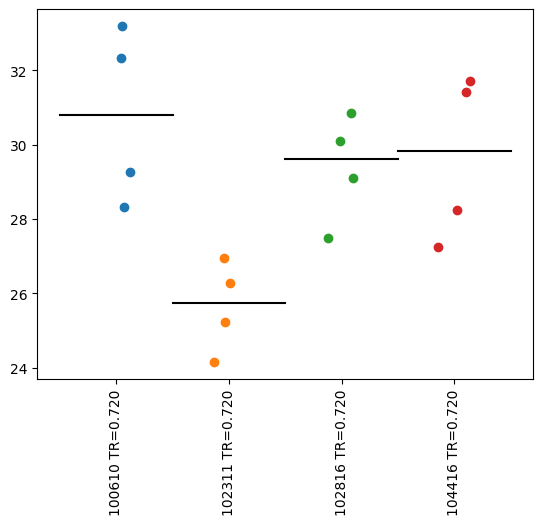

In [173]:
import matplotlib.pyplot as plt

c_idx = 0
labels = []

plt.figure()

median_vals = []
for x in range(len(results)):
    sub = to_analyze[x][1]
    trs = np.array(results[x][0])
    tsnr_medians = np.array(results[x][1])

    unique_trs = np.unique(trs)
    for y in range(len(unique_trs)):
        these_medians = tsnr_medians[trs==unique_trs[y]]
        these_medians = these_medians[these_medians>0]
        
        plt.plot((np.random.rand(these_medians.shape[0])-0.5)*0.3+c_idx, 
                 these_medians, 'o')
        plt.plot([c_idx-0.5, c_idx+0.5], np.zeros([2])+np.median(these_medians), 'k-')

        median_vals.append(np.median(these_medians))
        labels.append(sub + ' TR=' + f"{unique_trs[y]:.3f}")
        c_idx += 1

plt.gca().set_xticks(np.arange(0, c_idx))
plt.gca().set_xticklabels(labels, rotation=90)



In [148]:
median_vals

[np.float32(30.898277),
 np.float32(30.96202),
 np.float64(60.863525390625),
 np.float64(36.22117805480957),
 np.float64(33.17866325378418),
 np.float64(37.02754211425781),
 np.float64(50.804386138916016),
 np.float32(43.49361),
 np.float64(40.0318603515625),
 np.float32(41.760628)]

In [153]:
np.sqrt(1.080/0.802)

np.float64(1.1604453526378797)

In [154]:
np.exp(33.1/35)

np.float64(2.5746517589164153)

In [160]:
40*np.sqrt(1.080/0.720)

np.float64(48.98979485566357)

In [158]:
43*np.exp(39/35)/np.exp(33.1/35)

np.float64(50.895349006568836)

In [41]:
out_file, mean_tsnr, tsnr_medians = compute_mean_tsnr(bold_filenames)






/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-01_space-T1w_desc-preproc_bold.nii.gz
54.799747
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-02_space-T1w_desc-preproc_bold.nii.gz
51.080536
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-03_space-T1w_desc-preproc_bold.nii.gz
56.19424
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-04_space-T1w_desc-preproc_bold.nii.gz
56.095207
/juice6/u/nlp/climblab/BIDS/climblab_multisession/derivatives/preprocess/main/sub-c001/ses-ex31381/func/sub-c001_ses-ex31381_task-speechloc10_run-05_space-T1w_desc-preproc_bold.nii.gz
52.56671
/juice6/u/nlp/climblab/BIDS/clim

IndexError: boolean index did not match indexed array along axis 1; size of axis is 90 but size of corresponding boolean axis is 91

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(np.array(trs), np.array(tsnr_medians), 'o')
plt.show()

(72, 84, 71)

In [6]:
np.median(mean_tsnr[:])

np.float32(5.6563797)

In [33]:
#project raw bold onto the surface
anat_path = get_preprocessed_anat_dir(project, participant, preprocessing_label='main')

if os.path.basename(os.path.dirname(anat_path)).startswith('ses-'):
    ses_str_anat = f'_ses-{os.path.basename(os.path.dirname(anat_path))[4:]}'
else:
    ses_str_anat = ''

LWHITE = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_white.surf.gii")
LPIAL  = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_pial.surf.gii")
LMID   = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_midthickness.surf.gii")
RWHITE = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_white.surf.gii")
RPIAL  = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_pial.surf.gii")
RMID   = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_midthickness.surf.gii")

# One mapping per hemisphere -> multi-map metrics (one map per IC)
LMET = os.path.join(out_root, "tsnr_volume.L.func.gii")
RMET = os.path.join(out_root, "tsnr_volume.R.func.gii")

denoised = os.path.join(out_root, "tsnr_volume.nii.gz")
print(denoised)

container = '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif'
bind = '/juice6:/juice6'

# Map 4D volume -> multi-map metric
cx(container, home_dir, bind,
   f"wb_command -volume-to-surface-mapping {_shlex(denoised)} {_shlex(LMID)} {_shlex(LMET)} "
   f"-ribbon-constrained {_shlex(LWHITE)} {_shlex(LPIAL)}")
cx(container, home_dir, bind,
   f"wb_command -volume-to-surface-mapping {_shlex(denoised)} {_shlex(RMID)} {_shlex(RMET)} "
   f"-ribbon-constrained {_shlex(RWHITE)} {_shlex(RPIAL)}")

# Create a single multi-map dscalar from the two multi-map metrics
DS = os.path.join(out_root, "tsnr_volume.dtseries.nii")
cx(container, home_dir, bind,
   f"wb_command -cifti-create-dense-timeseries {_shlex(DS)} -left-metric {_shlex(LMET)} -right-metric {_shlex(RMET)} -timestep {TR} -timestart 0")


/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.nii.gz


singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -volume-to-surface-mapping '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.nii.gz'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-L_midthickness.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.L.func.gii'\'' -ribbon-constrained '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-L_white.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-L_pial.surf.gii'\'''




Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP

singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -volume-to-surface-mapping '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.nii.gz'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-R_midthickness.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.R.func.gii'\'' -ribbon-constrained '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-R_white.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-R_pial.surf.gii'\'''




Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP

singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -cifti-create-dense-timeseries '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.dtseries.nii'\'' -left-metric '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.L.func.gii'\'' -right-metric '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.R.func.gii'\'' -timestep 1.08 -timestart 0'




Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP